Notebook for testing plugin funcionalities

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.io import wavfile
from scipy.signal import butter, filtfilt

In [75]:
fs, data = wavfile.read("audio/in/flute_1.wav")
data = data[:,0]    #using only one channel
N = len(data)
length = N/fs
time = np.linspace(0, length, N)

/var/folders/qb/279v3kbj47ddq3xj8qvmb51w0000gn/T/ipykernel_55357/4283947090.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read("audio/in/flute_1.wav")


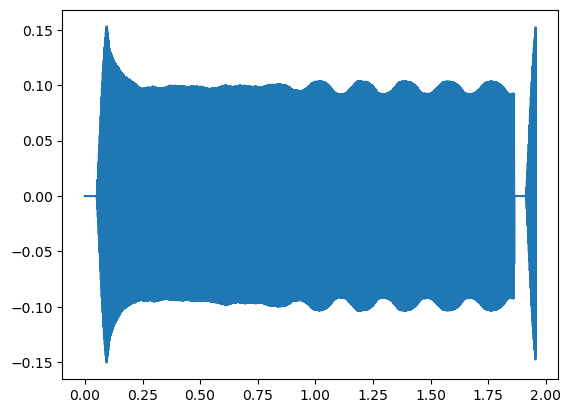

In [32]:
plt.plot(time,data)
plt.show()

FFT

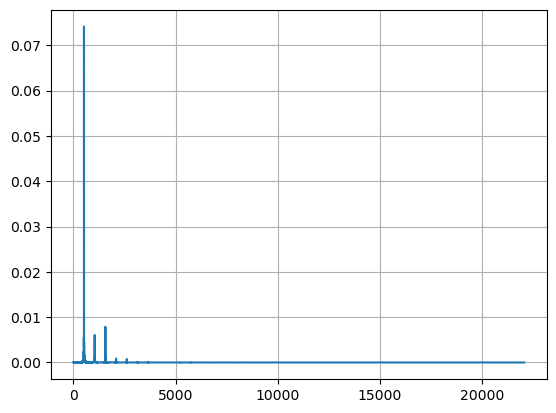

In [35]:
yf = fft(data)[:N//2]
xf = fftfreq(N, 1/fs)[:N//2]
plt.plot(xf, 2/N * np.abs(yf))
plt.grid()
plt.show()

Extraction of the dominant frequency

In [ ]:
max_idx = np.argmax(yf)
max_freq = xf[max_idx]
max_freq = round(max_freq)

523.8865129863357

Generating, chosen signal type with base frequency extracted from fft

SINE

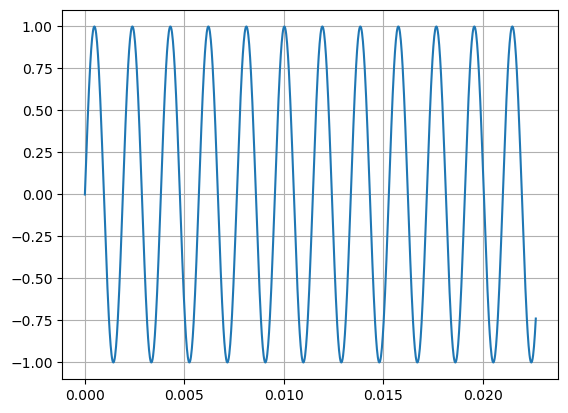

In [39]:
f = max_freq
t = time
sig = np.sin(2*np.pi*f*t) 
plt.plot(time[:1000],sig[:1000])
plt.grid()
plt.show()

SQUARE

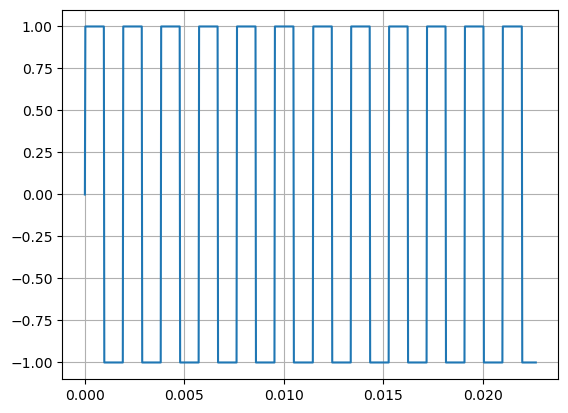

In [58]:
f = max_freq
t = time
sig = np.sign(np.sin(2*np.pi*f*t))
plt.plot(time[:1000],sig[:1000])
plt.grid()
plt.show()

SAWTOOTH

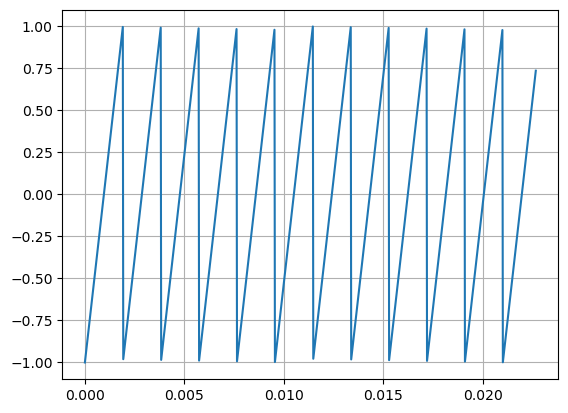

In [67]:
f = max_freq
t = time
sig = 2*(time*f % 1) - 1
plt.plot(time[:1000],sig[:1000])
plt.grid()
plt.show()

TRIANGLE

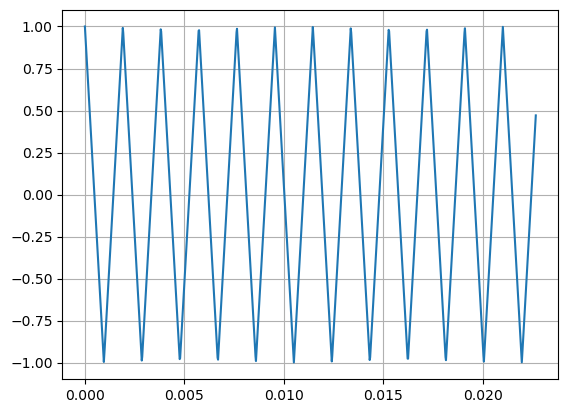

In [42]:
f = max_freq
t = time
sig = 2 * np.abs(2*(time * f % 1) - 1) - 1
plt.plot(time[:1000],sig[:1000])
plt.grid()
plt.show()

FILTERS

In [68]:
order = 4
cutoff = f+2000
nyq = fs//2
cutoff = cutoff/nyq
b, a = butter(order, cutoff, btype='low', analog=False)

sig_filtered = filtfilt(b,a,sig)

FFT comparison

In [69]:
#generated signal
yf = fft(sig)[:nyq]
xf = fftfreq(N, 1/fs)[:nyq]
#filtered_signal
yf_filt = fft(sig_filtered)[:nyq]
xf_filt = fftfreq(N, 1/fs)[:nyq]


PLOTTING

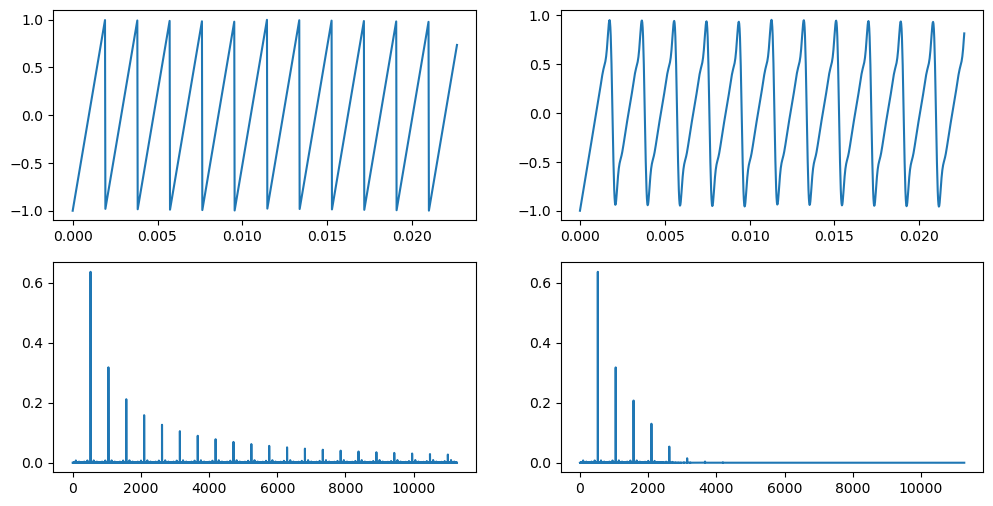

In [70]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.plot(time[:1000],sig[:1000])
plt.subplot(2,2,2)
plt.plot(time[:1000],sig_filtered[:1000])

plt.subplot(2,2,3)
plt.plot(xf,2/N*np.abs(yf))
plt.subplot(2,2,4)
plt.plot(xf_filt,2/N*np.abs(yf_filt))


Generating output wav

!!! nie puszczajcie czystego kwadratu za głośno i długo na głośnikach !!!

In [76]:
sig_int16 = (sig *32767).astype(np.int16)
wavfile.write('audio/out/raw_signal.wav', fs, sig_int16)

In [77]:
sig_filtered_int16 = (sig_filtered *32767).astype(np.int16)
wavfile.write('audio/out/filtered_signal.wav', fs, sig_filtered_int16)